# 05 · Cross-task generalization and true/false color

Task3 提供颜色感知训练集；Task2 同时提供灰色记忆与物体—颜色一致性条件。

In [1]:
# [Setup]
from pathlib import Path
import sys, numpy as np, pandas as pd
ROOT=Path('/home/lirui/liulab_project/ieeg/Project_colorieeg_2026'); PIPE=ROOT/'color_cognition_pipeline'/'analyse_0720'
sys.path.insert(0,str(PIPE)); import config
from utils.epochs import load_epochs
from utils.decoding import make_time_windows, temporal_generalization, decode_accuracy, decode_permutation
from utils.stats import cluster_permutation_1d

In [2]:
# [Cross-task] Train Task3 red/green and test Task2 gray memory
cand=pd.read_csv(config.subject_result_dir('test001')/'localizer'/'candidate_electrodes_10mm.csv')
channel_col=next(c for c in cand.columns if c.lower() in ('channel','channelname','name'))
t2=load_epochs(config.INTERMEDIATE_ROOT/'test001'/'preprocessing'/'task2_erp.npz'); t3=load_epochs(config.INTERMEDIATE_ROOT/'test001'/'preprocessing'/'task3_erp.npz')
common=[c for c in cand[channel_col].drop_duplicates() if c in t2['channel_names'] and c in t3['channel_names']]
p2=[list(t2['channel_names']).index(c) for c in common]; p3=[list(t3['channel_names']).index(c) for c in common]
g2=np.char.replace(t2['triggers'].astype(str),'Trigger-In:',''); g3=np.char.replace(t3['triggers'].astype(str),'Trigger-In:','')
m2=np.isin(g2,['123','133','103','113']); m3=np.isin(g3,['51','54'])
x2=t2['data'][m2][:,p2,:]; y2=np.isin(g2[m2],['103','113']).astype(int)
x3=t3['data'][m3][:,p3,:]; y3=(g3[m3]=='54').astype(int)
windows,centers=make_time_windows(t2['times_ms'],config.WINDOW_MS,config.STEP_MS)
tg_3_to_2=temporal_generalization(x3,x2,y3,y2,windows,config.RANDOM_SEED)
tg_2_to_3=temporal_generalization(x2,x3,y2,y3,windows,config.RANDOM_SEED)
out=config.subject_result_dir('test001')/'cross_task'; np.savez_compressed(out/'temporal_generalization.npz',task3_to_task2=tg_3_to_2.astype('float32'),task2_to_task3=tg_2_to_3.astype('float32'),time_ms=centers.astype('float32'),channels=np.asarray(common))

In [3]:
# [True/False] Leave one fruit out; do not call this a Task3 contrast
mapping={'101':('cabbage',1),'102':('cabbage',0),'111':('kiwi',1),'112':('kiwi',0),'121':('strawberry',1),'122':('strawberry',0),'131':('watermelon',1),'132':('watermelon',0)}
mask=np.isin(g2,list(mapping)); selected=g2[mask]
fruits=np.asarray([mapping[x][0] for x in selected]); y_tf=np.asarray([mapping[x][1] for x in selected]); x_tf=t2['data'][mask][:,p2,:]
cv_tf=[(np.flatnonzero(fruits!=fruit),np.flatnonzero(fruits==fruit)) for fruit in np.unique(fruits)]
score_tf=decode_accuracy(x_tf,y_tf,windows,cv_tf)
null_tf=decode_permutation(x_tf,y_tf,windows,cv_tf,config.N_PERMUTATIONS,config.RANDOM_SEED+1,config.N_JOBS)
p_tf=(1+(null_tf>=score_tf).sum(0))/(1+len(null_tf)); pc_tf=cluster_permutation_1d(score_tf,null_tf)
pd.DataFrame({'time_ms':centers,'accuracy':score_tf,'p_uncorrected':p_tf,'p_cluster':pc_tf}).to_csv(out/'true_false_decoding.csv',index=False)
pd.DataFrame({'trigger':selected,'fruit':fruits,'is_true':y_tf}).to_csv(out/'true_false_trial_table.csv',index=False)

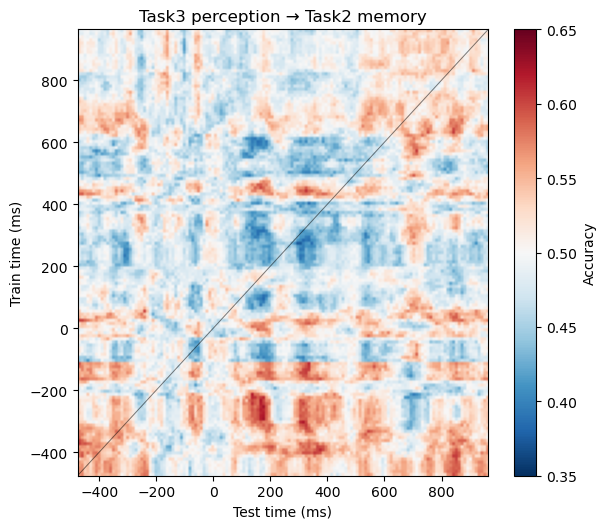

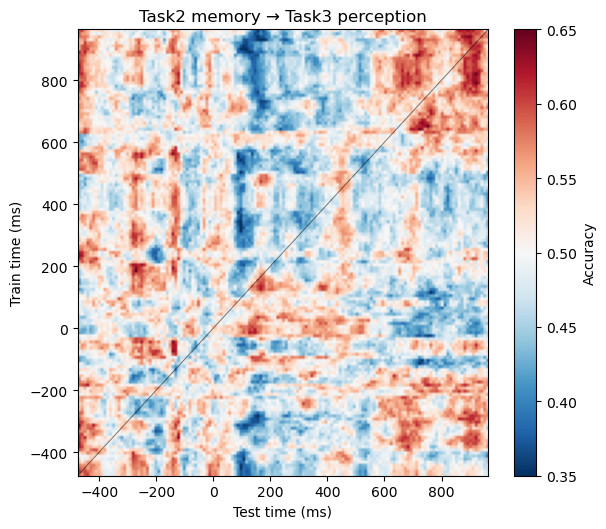

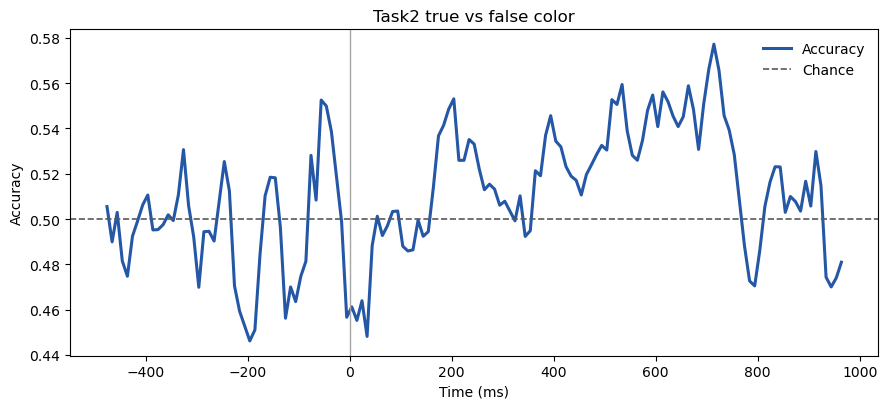

In [4]:
# [Plot] Display both TGM directions and true/false decoding
from utils.plotting import plot_tgm, plot_decoding
plot_tgm(tg_3_to_2,centers,'Task3 perception → Task2 memory',out/'task3_to_task2_tgm.png');
plot_tgm(tg_2_to_3,centers,'Task2 memory → Task3 perception',out/'task2_to_task3_tgm.png');
plot_decoding(centers,score_tf,pc_tf,'Task2 true vs false color',out/'true_false_decoding.png');